# Multi-Float Simulation Error Analysis

Discovers Argo floats that operated inside the CMEMS model domain, downloads their trajectory
files, reruns the simulation against each one using the **reset-per-cycle** approach, and
aggregates the position errors across all floats.

**Workflow:**
1. **Cell 1** — reads `manifest.yaml`, queries the Argo index, shows a map of floats in the domain.
2. **Cell 2** — edit `WMOS_TO_ANALYZE` with WMOs from the map.
3. **Cell 3** — downloads `{WMO}_Rtraj.nc` from the Argo GDAC for each selected float.
4. **Cells 4–7** — setup, helpers, simulation loop, aggregate plots.

Run all: `Kernel › Restart & Run All`

In [1]:
# ── Cell 1: Discover floats in the CMEMS domain ──────────────────────────────
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import plotly.graph_objects as go

_src_dir = Path("~/Documents/argo_piloting/sim/src").expanduser()
if str(_src_dir) not in sys.path:
    sys.path.insert(0, str(_src_dir))
from data_loader import load_manifest

DATA_DIR      = Path("~/Documents/argo_piloting/sim/data/raw").expanduser()
ARGO_DATA_DIR = Path("~/Documents/argo_piloting/sim/data/argo_data").expanduser()

# ── Derive CMEMS domain from manifest ────────────────────────────────────────
manifest = load_manifest(DATA_DIR)

lat_min = min(e["lat"][0] for e in manifest)
lat_max = max(e["lat"][1] for e in manifest)
lon_min = min(e["lon"][0] for e in manifest)
lon_max = max(e["lon"][1] for e in manifest)
t_start = min(datetime.fromisoformat(e["time"][0]) for e in manifest)
t_end   = max(datetime.fromisoformat(e["time"][1]) for e in manifest)

print(f"CMEMS domain : lat=[{lat_min:.2f}, {lat_max:.2f}]  lon=[{lon_min:.2f}, {lon_max:.2f}]")
print(f"Time window  : {t_start.date()} → {t_end.date()}")

# ── Load Argo global index and filter to CMEMS domain ────────────────────────
from argopy import ArgoIndex

print("\nLoading Argo global index...")
df_all = ArgoIndex().load().to_dataframe()

mask = (
    (df_all["latitude"]  >= lat_min) & (df_all["latitude"]  <= lat_max) &
    (df_all["longitude"] >= lon_min) & (df_all["longitude"] <= lon_max) &
    (df_all["date"] >= pd.Timestamp(t_start)) &
    (df_all["date"] <= pd.Timestamp(t_end))
)
_df = df_all[mask].copy()

_wmo_to_dac = _df.drop_duplicates("wmo").set_index("wmo")["dac"].to_dict()

summary = (
    _df.groupby("wmo")
    .agg(n_profiles=("date", "count"),
         first_profile=("date", "min"),
         last_profile=("date", "max"))
    .sort_values("n_profiles", ascending=False)
    .reset_index()
)

print(f"\nFound {len(summary)} floats with {len(_df)} total profiles:")
print(summary.to_string(index=False))

# ── Map ───────────────────────────────────────────────────────────────────────
fig = go.Figure()
fig.add_trace(go.Scattergeo(
    lon=[lon_min, lon_max, lon_max, lon_min, lon_min],
    lat=[lat_min, lat_min, lat_max, lat_max, lat_min],
    mode="lines", line=dict(color="cyan", width=2, dash="dash"),
    name="CMEMS domain",
))
for wmo in summary["wmo"]:
    pts = _df[_df["wmo"] == wmo].sort_values("date")
    fig.add_trace(go.Scattergeo(
        lon=pts["longitude"], lat=pts["latitude"],
        mode="lines+markers", marker=dict(size=3), line=dict(width=1),
        name=str(wmo),
        hovertemplate=f"WMO {wmo}<br>%{{lat:.3f}}°N %{{lon:.3f}}°E<extra></extra>",
    ))
fig.update_layout(
    title=f"Argo floats in CMEMS domain — {len(summary)} floats",
    geo=dict(
        scope="europe",
        center=dict(lat=(lat_min + lat_max) / 2, lon=(lon_min + lon_max) / 2),
        projection_scale=6,
        showland=True,  landcolor="rgb(40,40,40)",
        showocean=True, oceancolor="rgb(10,30,60)",
        showcoastlines=True, coastlinecolor="grey", showframe=False,
    ),
    paper_bgcolor="rgb(15,20,40)", font_color="white", height=600,
    legend=dict(title="WMO", bgcolor="rgba(0,0,0,0.5)"),
)
fig.show()

CMEMS domain : lat=[53.50, 56.50]  lon=[12.50, 18.00]
Time window  : 2023-10-01 → 2025-01-31


/home/ddyob/Documents/argo_piloting/sim/.venv/bin/python: No module named pip



Loading Argo global index...

Found 6 floats with 1068 total profiles:
    wmo  n_profiles       first_profile        last_profile
4903784         317 2023-11-07 20:40:05 2025-01-27 11:50:38
3902117         285 2023-10-01 08:14:30 2024-02-24 06:20:30
2903902         175 2024-03-22 18:11:31 2025-01-26 13:43:28
1902682         154 2023-10-02 09:28:30 2024-02-23 19:25:00
7902194         120 2024-05-28 12:02:00 2025-01-31 19:31:30
7900584          17 2023-10-03 10:29:10 2023-12-22 10:38:51


In [2]:
# ── Cell 2: Select floats to analyse ─────────────────────────────────────────
# Add WMO numbers from the map above.
WMOS_TO_ANALYZE = [
    7902194,
    4903784,
    1902682,
    7900584,
    3902117
]

In [17]:
# ── Cell 3: Download Rtraj files from Argo GDAC ───────────────────────────────
import urllib.request

# Use WMO→DAC mapping from Cell 1; re-query if this cell runs standalone.
try:
    wmo_to_dac = _wmo_to_dac
except NameError:
    print("Re-loading Argo index for DAC info...")
    import pandas as pd
    from argopy import ArgoIndex
    _fb = ArgoIndex().load().to_dataframe()
    wmo_to_dac = _fb.drop_duplicates("wmo").set_index("wmo")["dac"].to_dict()

for wmo in WMOS_TO_ANALYZE:
    out_dir  = ARGO_DATA_DIR / f"argo_{wmo}"
    out_path = out_dir / f"{wmo}_Rtraj.nc"

    if out_path.exists():
        print(f"WMO {wmo}: Rtraj already present — skipping.")
        continue

    dac = wmo_to_dac.get(wmo)
    if dac is None:
        print(f"WMO {wmo}: DAC not found in index — skipping.")
        continue

    url = f"https://data-argo.ifremer.fr/dac/{dac}/{wmo}/{wmo}_Rtraj.nc"
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f"WMO {wmo}: downloading from {url} ...")
    urllib.request.urlretrieve(url, out_path)
    size_mb = out_path.stat().st_size / 1e6
    print(f"WMO {wmo}: saved {size_mb:.1f} MB → {out_path}")

print("\nDone.")

WMO 7902194: Rtraj already present — skipping.
WMO 4903784: Rtraj already present — skipping.
WMO 1902682: Rtraj already present — skipping.
WMO 7900584: Rtraj already present — skipping.
WMO 3902117: Rtraj already present — skipping.

Done.


In [18]:
# ── Cell 4: Setup — imports, manifest, bathymetry ─────────────────────────────
import math
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import sys
from pathlib import Path

_nb_dir  = Path("~/Documents/argo_piloting/sim/notebooks/Q_derivation").expanduser()
_src_dir = Path("~/Documents/argo_piloting/sim/src").expanduser()
# nb_dir inserted last → ends up at sys.path[0], so local sim_types/particle_mover
# shadow the src versions; data_loader falls through to src.
for p in [str(_src_dir), str(_nb_dir)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from sim_types import ControlAction, GeoLocation, ProfilerState
from particle_mover import run_until_next_action
from data_loader import (
    load_manifest, load_bathymetry, build_bathymetry_interpolator
)

DATA_DIR      = Path("~/Documents/argo_piloting/sim/data/raw").expanduser()
ARGO_DATA_DIR = Path("~/Documents/argo_piloting/sim/data/argo_data").expanduser()
BATHY_PATH    = DATA_DIR / "D6_2024.nc"

manifest     = load_manifest(DATA_DIR)
bathy_ds     = load_bathymetry(BATHY_PATH)
bathy_interp = build_bathymetry_interpolator(bathy_ds)

t_start = min(datetime.fromisoformat(e["time"][0]) for e in manifest)
t_end   = max(datetime.fromisoformat(e["time"][1]) for e in manifest)

print(f"Manifest: {len(manifest)} tiles | CMEMS window: {t_start.date()} → {t_end.date()}")
print("Bathymetry loaded.")

Manifest: 400 tiles | CMEMS window: 2023-10-01 → 2025-01-31
Bathymetry loaded.


In [29]:
# ── Cell 5: Helper functions ───────────────────────────────────────────────────

DESC_CODE    = 190
PARKING_CODE = 290
ASC_CODE     = 590

DRIFT_THRESH_KM   = 0.1   # surface drift ≤ this → parked_on_bottom
DEPTH_FRAC_THRESH = 0.99  # avg_parking_depth / bathy ≥ this → parked_on_bottom


def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return 6371.0 * 2 * math.asin(math.sqrt(a))


def _speed_from_pres_juld(sub_ds):
    """Mean dbar/s slope from a sub-dataset with PRES and JULD."""
    pres = sub_ds.PRES.values.astype(float)
    juld = sub_ds.JULD.values
    dt_s = np.diff(juld) / np.timedelta64(1, "s")
    valid = dt_s != 0
    if not valid.any():
        return None
    return float(np.nanmean(np.diff(pres)[valid] / dt_s[valid]))


def extract_cycles(rtraj_path, bathy_interp):
    """Derive per-cycle metadata from an Argo Rtraj NetCDF file."""
    ds = xr.open_dataset(rtraj_path)
    all_cycles = [int(c) for c in np.unique(ds.CYCLE_NUMBER.values)
                  if not np.isnan(float(c))]
    cycle_numbers = sorted(all_cycles)

    # ── Pass 1: per-cycle positions, timing, speeds, parking depth ────────────
    meta = {}
    for cyc in cycle_numbers:
        mask     = ds.CYCLE_NUMBER.values == cyc
        cyc_ds   = ds.isel(N_MEASUREMENT=mask)
        juld     = cyc_ds.JULD.values
        valid_t  = juld[~np.isnat(juld)]
        if len(valid_t) == 0:
            continue

        lats     = cyc_ds.LATITUDE.values.astype(float)
        lons     = cyc_ds.LONGITUDE.values.astype(float)
        pos_mask = ~np.isnan(lats) & ~np.isnan(lons)
        if not pos_mask.any():
            continue

        codes    = cyc_ds.MEASUREMENT_CODE.values
        desc_ds  = cyc_ds.isel(N_MEASUREMENT=codes == DESC_CODE)
        asc_ds   = cyc_ds.isel(N_MEASUREMENT=codes == ASC_CODE)
        park_ds  = cyc_ds.isel(N_MEASUREMENT=codes == PARKING_CODE)

        desc_t   = desc_ds.JULD.values; desc_t = desc_t[~np.isnat(desc_t)]
        asc_t    = asc_ds.JULD.values;  asc_t  = asc_t[~np.isnat(asc_t)]

        pres = park_ds.PRES.values.astype(float)
        pres = pres[~np.isnan(pres)]

        start_lat = float(lats[pos_mask][0])
        start_lon = float(lons[pos_mask][0])
        last_lat  = float(lats[pos_mask][-1])
        last_lon  = float(lons[pos_mask][-1])
        bathy_depth_m = float(bathy_interp(start_lat, start_lon))

        depth_based_parked = False
        avg_bottom_depth_dbar = None
        if len(pres) > 0:
            avg_bottom_depth_dbar = float(np.mean(pres))
            if not math.isnan(bathy_depth_m) and bathy_depth_m > 0:
                depth_based_parked = bool(
                    avg_bottom_depth_dbar / bathy_depth_m >= DEPTH_FRAC_THRESH
                )

        meta[cyc] = dict(
            cycle=cyc,
            start_lat=start_lat,
            start_lon=start_lon,
            last_lat=last_lat,
            last_lon=last_lon,
            start_time=str(valid_t[0]),
            end_time=str(valid_t[-1]),
            first_desc_juld=desc_t[0]  if len(desc_t) > 0 else valid_t[0],
            last_asc_juld=asc_t[-1]    if len(asc_t)  > 0 else valid_t[-1],
            descent_speed_dbar_s=_speed_from_pres_juld(desc_ds)
                                 if len(desc_ds.N_MEASUREMENT) >= 2 else None,
            ascent_speed_dbar_s=_speed_from_pres_juld(asc_ds)
                                if len(asc_ds.N_MEASUREMENT) >= 2 else None,
            avg_bottom_depth_dbar=avg_bottom_depth_dbar,
            bathy_depth_m=bathy_depth_m,
            depth_based_parked=depth_based_parked,
            parked_on_bottom=False,   # default; overwritten in Pass 2
        )

    # ── Pass 2: surface drift + depth match → parked_on_bottom ───────────────
    for i, cyc in enumerate(cycle_numbers[:-1]):
        nxt = cycle_numbers[i + 1]
        if cyc not in meta or nxt not in meta:
            continue
        m, nm = meta[cyc], meta[nxt]
        surf_min = float(
            (nm["first_desc_juld"] - m["last_asc_juld"]) / np.timedelta64(1, "m")
        )
        dlat_m = (nm["start_lat"] - m["last_lat"]) * 111320.0
        dlon_m = ((nm["start_lon"] - m["last_lon"])
                  * 111320.0 * math.cos(math.radians(m["last_lat"])))
        drift_km = math.sqrt(dlat_m ** 2 + dlon_m ** 2) / 1000.0
        m["surface_duration_min"] = round(max(surf_min, 0.0), 1)
        m["drift_km"]             = round(drift_km, 3)
        m["parked_on_bottom"]     = (drift_km <= DRIFT_THRESH_KM) or m.get("depth_based_parked", False)

    # Default for last cycle
    if cycle_numbers and cycle_numbers[-1] in meta:
        last = meta[cycle_numbers[-1]]
        last.setdefault("surface_duration_min", 30.0)
        last.setdefault("drift_km", None)
        last.setdefault("parked_on_bottom", False)

    # ── Fill missing speeds with per-float mean ────────────────────────────────
    desc_speeds = [v["descent_speed_dbar_s"] for v in meta.values()
                   if v["descent_speed_dbar_s"] is not None]
    asc_speeds  = [v["ascent_speed_dbar_s"]  for v in meta.values()
                   if v["ascent_speed_dbar_s"]  is not None]
    mean_desc = float(np.mean(desc_speeds)) if desc_speeds else 0.08
    mean_asc  = float(np.mean(asc_speeds))  if asc_speeds  else 0.08
    for v in meta.values():
        if v["descent_speed_dbar_s"] is None:
            v["descent_speed_dbar_s"] = mean_desc
        if v["ascent_speed_dbar_s"] is None:
            v["ascent_speed_dbar_s"] = mean_asc

    ds.close()
    return [meta[c] for c in cycle_numbers if c in meta]


def action_from_cycle(cyc, next_cyc):
    """Build a ControlAction from a cycle dict and the following cycle dict."""
    t_start  = np.datetime64(cyc["start_time"])
    t_next   = np.datetime64(next_cyc["start_time"])
    surf_min = float(cyc.get("surface_duration_min") or 30.0)

    try:
        asc_s = cyc["avg_bottom_depth_dbar"] / abs(cyc["ascent_speed_dbar_s"])
        cycle_hours = float(
            (t_next - t_start
             - np.timedelta64(int(surf_min), "m")
             - np.timedelta64(int(asc_s), "s"))
            / np.timedelta64(1, "h")
        )
    except Exception:
        cycle_hours = float((t_next - t_start) / np.timedelta64(1, "h"))

    if cyc.get("parked_on_bottom", False):
        park_mode = "park_on_bottom"
    elif cyc.get("avg_bottom_depth_dbar") is not None:
        park_mode = "parking_depth"
    else:
        park_mode = "drift_on_surface"

    return ControlAction(
        park_mode=park_mode,
        cycle_hours=max(cycle_hours, 0.5),
        transmission_duration_minutes=surf_min,
        target_depth=cyc.get("avg_bottom_depth_dbar"),
        descent_speed_ms=abs(cyc["descent_speed_dbar_s"]),
        ascent_speed_ms=abs(cyc["ascent_speed_dbar_s"]),
    )


print("Helpers defined.")

Helpers defined.


In [ ]:
# ── Cell 6: Run reset simulation for every float and cycle ────────────────────
MAX_DEPTH_M  = 150   # skip cycles with unrealistic or unknown parking depth
FORCE_RERUN  = True  # set False to load from cache after first run
CACHE_PATH   = Path("~/Documents/argo_piloting/sim/notebooks/Q_derivation/multi_float_errors_cache_no_bottom_park.parquet").expanduser()

if not FORCE_RERUN and CACHE_PATH.exists():
    all_df = pd.read_parquet(CACHE_PATH)
    all_results = {
        wmo: all_df[all_df["wmo"] == wmo].to_dict("records")
        for wmo in all_df["wmo"].unique()
    }
    print(f"Loaded {len(all_df)} rows from cache ({CACHE_PATH.name}).")
    print(f"Floats: {sorted(all_df['wmo'].unique())}  |  cycles: {len(all_df)}")
else:
    t_start_np = np.datetime64(t_start)
    t_end_np   = np.datetime64(t_end)

    all_results = {}

    for wmo in WMOS_TO_ANALYZE:
        rtraj_path = ARGO_DATA_DIR / f"argo_{wmo}" / f"{wmo}_Rtraj.nc"
        if not rtraj_path.exists():
            print(f"WMO {wmo}: Rtraj not found — skipping (run Cell 3 first).")
            continue

        print(f"\nWMO {wmo}: extracting cycles...")
        cycles = extract_cycles(rtraj_path, bathy_interp)
        cycles = [c for c in cycles
                  if t_start_np <= np.datetime64(c["start_time"]) <= t_end_np]
        print(f"  {len(cycles)} cycles in CMEMS window")

        float_errors = []
        for i, cyc in enumerate(cycles[:-1]):
            next_cyc = cycles[i + 1]
            try:
                action = action_from_cycle(cyc, next_cyc)

                # Skip cycles that would cause runaway descent:
                #   (a) explicit parking depth exceeds the cap
                target_depth = cyc.get("avg_bottom_depth_dbar") or 0.0
                if target_depth > MAX_DEPTH_M:
                    print(f"  Cycle {cyc['cycle']}: skipping — target depth {target_depth:.0f} m > {MAX_DEPTH_M} m limit")
                    continue
                #   (b) park_on_bottom with unknown/unreliable bathymetry → infinite descent
                bathy_depth = cyc.get("bathy_depth_m", float("nan"))
                if cyc.get("parked_on_bottom") and (math.isnan(bathy_depth) or bathy_depth > MAX_DEPTH_M):
                    print(f"  Cycle {cyc['cycle']}: skipping — park_on_bottom with bathy={bathy_depth:.0f} m")
                    continue

                start_dt = pd.Timestamp(cyc["start_time"]).to_pydatetime().replace(tzinfo=None)
                state = ProfilerState(
                    time=start_dt,
                    location=GeoLocation(lat=cyc["start_lat"], lon=cyc["start_lon"]),
                    depth=0.0,
                    phase="communicating",
                    x=0.0,
                    y=0.0,
                    bathymetry_depth=bathy_interp(cyc["start_lat"], cyc["start_lon"]),
                )

                _, end_state = run_until_next_action(
                    state, DATA_DIR, manifest, bathy_interp, action,
                    dt_vertical_seconds=30,
                )
                error_km = haversine_km(
                    end_state.location.lat, end_state.location.lon,
                    next_cyc["start_lat"], next_cyc["start_lon"],
                )

                x_res_m = ((next_cyc["start_lon"] - end_state.location.lon)
                           * 111_320.0 * math.cos(math.radians(next_cyc["start_lat"])))
                y_res_m = (next_cyc["start_lat"] - end_state.location.lat) * 111_320.0

                T_s = (pd.Timestamp(next_cyc["start_time"])
                       - pd.Timestamp(cyc["start_time"])).total_seconds()
                depth     = cyc.get("avg_bottom_depth_dbar") or 0.0
                v_desc    = abs(cyc["descent_speed_dbar_s"])
                v_asc     = abs(cyc["ascent_speed_dbar_s"])
                T_transit = (depth / v_desc + depth / v_asc) if (depth > 0 and v_desc > 0 and v_asc > 0) else 0.0
                T_drift_s = max(T_s - T_transit, T_s * 0.5)

                float_errors.append({
                    "wmo":                  wmo,
                    "cycle":                cyc["cycle"],
                    "start_time":           cyc["start_time"],
                    "error_km":             error_km,
                    "sim_lat":              end_state.location.lat,
                    "sim_lon":              end_state.location.lon,
                    "real_lat":             next_cyc["start_lat"],
                    "real_lon":             next_cyc["start_lon"],
                    "park_mode":            action.park_mode,
                    "cycle_hours":          action.cycle_hours,
                    "x_res_m":              x_res_m,
                    "y_res_m":              y_res_m,
                    "T_s":                  T_s,
                    "T_drift_s":            T_drift_s,
                    "parked_on_bottom":     bool(cyc.get("parked_on_bottom", False)),
                    # diagnostic fields
                    "avg_bottom_depth_dbar": cyc.get("avg_bottom_depth_dbar"),
                    "bathy_depth_m":         cyc.get("bathy_depth_m"),
                    "drift_km":              cyc.get("drift_km"),
                    "surface_duration_min":  cyc.get("surface_duration_min"),
                })
            except Exception as exc:
                print(f"  Cycle {cyc['cycle']}: skipping — {exc}")

        all_results[wmo] = float_errors
        errs = [r["error_km"] for r in float_errors]
        if errs:
            print(f"  n={len(errs)} | "
                  f"mean={np.mean(errs):.2f} km | "
                  f"median={np.median(errs):.2f} km | "
                  f"max={np.max(errs):.2f} km")

    all_df = pd.DataFrame([r for rows in all_results.values() for r in rows])
    all_df.to_parquet(CACHE_PATH, index=False)
    print(f"\nTotal: {len(all_df)} cycles across {all_df['wmo'].nunique()} floats.")
    print(f"Saved to {CACHE_PATH.name}.")


WMO 7902194: extracting cycles...


/tmp/ipykernel_424113/425951805.py:32: FutureWarning: In a future version, xarray will not decode the variable 'CLOCK_OFFSET' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(rtraj_path)


  122 cycles in CMEMS window


/tmp/ipykernel_424113/2390616765.py:50: UserWarning: Discarding nonzero nanoseconds in conversion.
  start_dt = pd.Timestamp(cyc["start_time"]).to_pydatetime().replace(tzinfo=None)
NaN velocity at lat=55.0825 lon=16.1966 depth=70.3 bathy=78.4 time=2024-06-18 18:26:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.0825 lon=16.1966 depth=71.4 bathy=78.4 time=2024-06-18 18:27:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.0825 lon=16.1966 depth=72.6 bathy=78.4 time=2024-06-18 18:27:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.0825 lon=16.1966 depth=73.7 bathy=78.4 time=2024-06-18 18:28:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.0825 lon=16.1966 depth=74.9 bathy=78.4 time=2024-06-18 18:28:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.0825 lon=16.1966 depth=76.0 bathy=78.4 time=2024-06-18 18:29:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.0825 lon=16.1966 depth

  Cycle 38: skipping — No tiles found for lat=54.897 lon=19.343 time=[2024-08-13 23:57:00, 2024-08-16 13:14:12] margin=0.5°. Float may have left the dataset domain.


...

  Cycle 62: skipping — index 0 is out of bounds for axis 0 with size 0


NaN velocity at lat=55.3092 lon=15.5129 depth=78.0 bathy=85.6 time=2024-01-17 13:50:00 — defaulting to 0 during phase parking
NaN velocity at lat=55.3092 lon=15.5129 depth=78.0 bathy=85.6 time=2024-01-17 14:40:00 — defaulting to 0 during phase parking
NaN velocity at lat=55.3092 lon=15.5129 depth=78.0 bathy=85.6 time=2024-01-17 15:30:00 — defaulting to 0 during phase parking
NaN velocity at lat=55.3092 lon=15.5129 depth=78.0 bathy=85.6 time=2024-01-17 16:20:00 — defaulting to 0 during phase parking
NaN velocity at lat=55.3092 lon=15.5129 depth=78.0 bathy=85.6 time=2024-01-17 17:10:00 — defaulting to 0 during phase parking
5 consecutive NaN velocities at depth=78.0 (bathy=85.6) during phase parking — treating as on_seabed and skipping to 2024-01-19 02:24:03
NaN velocity at lat=55.3092 lon=15.5129 depth=78.0 bathy=85.6 time=2024-01-19 02:24:03 — defaulting to 0 during phase ascending
NaN velocity at lat=55.3092 lon=15.5129 depth=76.7 bathy=85.6 time=2024-01-19 02:24:33 — defaulting to 0 

  n=74 | mean=17.91 km | median=6.98 km | max=198.82 km

WMO 7900584: extracting cycles...


/tmp/ipykernel_424113/425951805.py:32: FutureWarning: In a future version, xarray will not decode the variable 'CLOCK_OFFSET' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(rtraj_path)


  100 cycles in CMEMS window


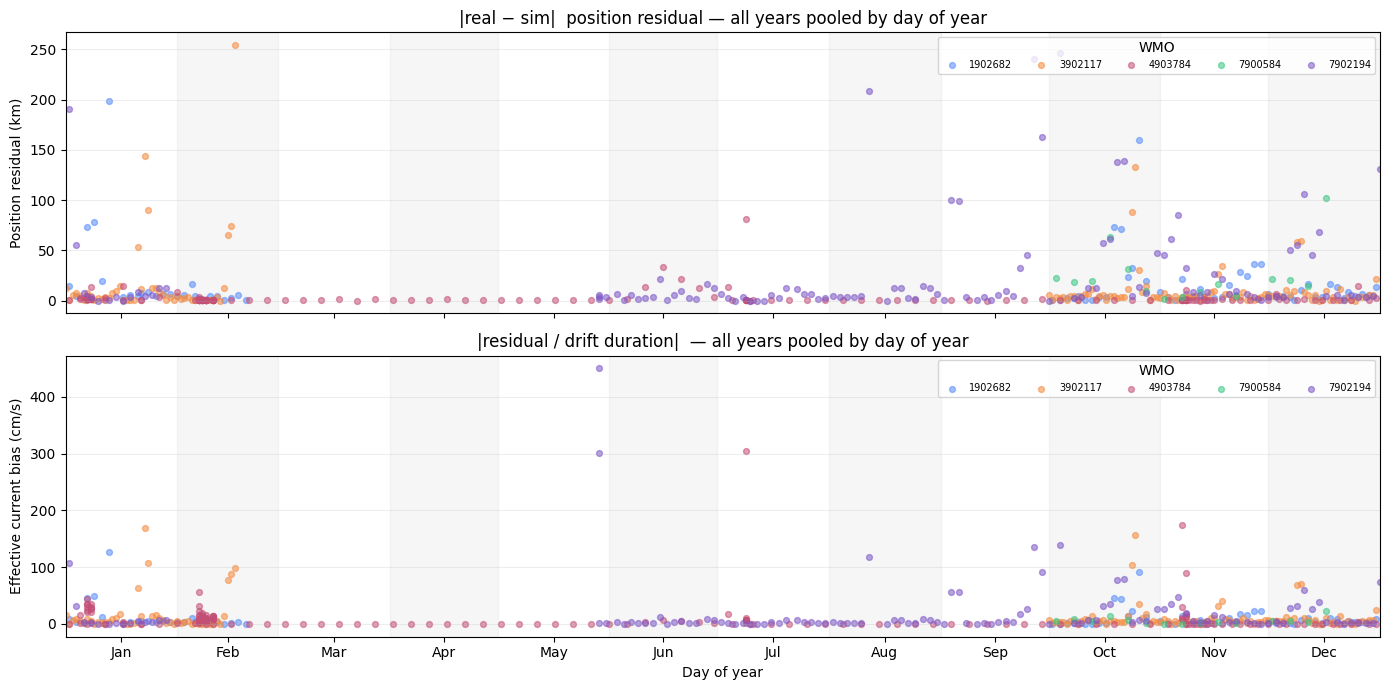

In [26]:
# ── Cell 6b: Seasonal scatter — position residual & current bias vs day-of-year
import matplotlib.pyplot as plt

_month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335, 366]
_month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

colours    = plt.rcParams["axes.prop_cycle"].by_key()["color"]
wmo_list   = sorted(all_df["wmo"].unique())
colour_map = {wmo: colours[i % len(colours)] for i, wmo in enumerate(wmo_list)}

fig, (ax_pos, ax_bias) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for wmo in wmo_list:
    sub     = all_df[all_df["wmo"] == wmo].copy()
    doy     = pd.to_datetime(sub["start_time"]).dt.day_of_year.values
    pos_km  = np.sqrt(sub["x_res_m"].values**2 + sub["y_res_m"].values**2) / 1000.0
    bias_cm = np.sqrt((sub["x_res_m"].values / sub["T_drift_s"].values)**2 +
                      (sub["y_res_m"].values / sub["T_drift_s"].values)**2) * 100.0

    ax_pos.scatter(doy, pos_km,  alpha=0.55, s=18, color=colour_map[wmo], label=str(wmo))
    ax_bias.scatter(doy, bias_cm, alpha=0.55, s=18, color=colour_map[wmo], label=str(wmo))

for ax in (ax_pos, ax_bias):
    # shade alternate months for readability
    for k in range(12):
        if k % 2 == 1:
            ax.axvspan(_month_starts[k], _month_starts[k + 1],
                       color="grey", alpha=0.07, zorder=0)
    ax.set_xticks([(_month_starts[k] + _month_starts[k + 1]) / 2 for k in range(12)])
    ax.set_xticklabels(_month_labels)
    ax.set_xlim(1, 366)
    ax.grid(axis="y", lw=0.4, alpha=0.4)
    ax.legend(title="WMO", fontsize=7, ncol=len(wmo_list), loc="upper right")

ax_pos.set_ylabel("Position residual (km)")
ax_pos.set_title("|real − sim|  position residual — all years pooled by day of year")

ax_bias.set_ylabel("Effective current bias (cm/s)")
ax_bias.set_title("|residual / drift duration|  — all years pooled by day of year")
ax_bias.set_xlabel("Day of year")

plt.tight_layout()
plt.show()

In [22]:
# ── Cell 6c: Map of high-error cycles — trajectories + error vectors ──────────
import plotly.graph_objects as go
import plotly.express as px

TOP_N = 25   # number of highest-error cycles to highlight

# Reconstruct cycle start positions from the preceding cycle's real end
df_s = all_df.sort_values(["wmo", "cycle"]).copy()
df_s["cyc_start_lat"] = df_s.groupby("wmo")["real_lat"].shift(1)
df_s["cyc_start_lon"] = df_s.groupby("wmo")["real_lon"].shift(1)

top = df_s.nlargest(TOP_N, "error_km").copy()

# Colour palette — one colour per WMO
palette   = px.colors.qualitative.Plotly
wmo_list  = sorted(all_df["wmo"].unique())
wmo_color = {wmo: palette[i % len(palette)] for i, wmo in enumerate(wmo_list)}

# park_mode → marker symbol for error-vector endpoints
mode_symbol = {
    "park_on_bottom":   "square",
    "parking_depth":    "circle",
    "drift_on_surface": "diamond",
}

fig = go.Figure()

# ── Background: all real surfacings per float ─────────────────────────────────
for wmo in wmo_list:
    sub = df_s[df_s["wmo"] == wmo].sort_values("cycle")
    fig.add_trace(go.Scattergeo(
        lon=sub["real_lon"], lat=sub["real_lat"],
        mode="lines+markers",
        line=dict(color=wmo_color[wmo], width=0.8),
        marker=dict(size=4, opacity=0.3, color=wmo_color[wmo]),
        name=f"WMO {wmo}",
        legendgroup=str(wmo),
        showlegend=True,
        hovertemplate=f"WMO {wmo}<br>%{{lat:.3f}}°N %{{lon:.3f}}°E<extra></extra>",
    ))

# ── Top-N cycles: start → sim_end (orange dash) & start → real_end (blue dash)
for _, row in top.iterrows():
    has_start = not (pd.isna(row["cyc_start_lat"]) or pd.isna(row["cyc_start_lon"]))
    label = (f"WMO {row['wmo']} C{int(row['cycle'])}  "
             f"{row['error_km']:.0f} km  [{row['park_mode']}]")
    sym = mode_symbol.get(row["park_mode"], "circle")

    if has_start:
        # Predicted path: start → sim_end
        fig.add_trace(go.Scattergeo(
            lon=[row["cyc_start_lon"], row["sim_lon"]],
            lat=[row["cyc_start_lat"], row["sim_lat"]],
            mode="lines", line=dict(color="orange", width=1.5, dash="dot"),
            showlegend=False, hoverinfo="skip",
        ))
        # Real path: start → real_end
        fig.add_trace(go.Scattergeo(
            lon=[row["cyc_start_lon"], row["real_lon"]],
            lat=[row["cyc_start_lat"], row["real_lat"]],
            mode="lines", line=dict(color="deepskyblue", width=1.5, dash="dot"),
            showlegend=False, hoverinfo="skip",
        ))

    # Error vector: sim_end → real_end  (red line)
    fig.add_trace(go.Scattergeo(
        lon=[row["sim_lon"], row["real_lon"]],
        lat=[row["sim_lat"], row["real_lat"]],
        mode="lines+markers",
        line=dict(color="red", width=2),
        marker=dict(
            size=[10, 12],
            symbol=["x", sym],
            color=["orange", "deepskyblue"],
        ),
        name=label,
        legendgroup="errors",
        legendgrouptitle_text="High-error cycles" if _ == top.index[0] else "",
        showlegend=True,
        hovertemplate=(
            f"WMO {row['wmo']}  Cycle {int(row['cycle'])}<br>"
            f"Error: {row['error_km']:.1f} km<br>"
            f"park_mode: {row['park_mode']}<br>"
            f"parked_on_bottom: {row['parked_on_bottom']}<br>"
            f"cycle_hours: {row['cycle_hours']:.1f} h<br>"
            "orange X = sim end  ·  blue = real end<extra></extra>"
        ),
    ))

lat_c = (all_df["real_lat"].mean())
lon_c = (all_df["real_lon"].mean())

fig.update_layout(
    title=f"Top-{TOP_N} error cycles  |  orange X = sim end  ·  blue marker = real end  ·  red line = error vector",
    geo=dict(
        scope="europe",
        center=dict(lat=lat_c, lon=lon_c),
        projection_scale=5,
        showland=True,  landcolor="rgb(40,40,40)",
        showocean=True, oceancolor="rgb(10,30,60)",
        showcoastlines=True, coastlinecolor="grey", showframe=False,
    ),
    paper_bgcolor="rgb(15,20,40)", font_color="white",
    height=650,
    legend=dict(bgcolor="rgba(0,0,0,0.5)", font_size=9),
)
fig.show()

# ── Diagnostic table ───────────────────────────────────────────────────────────
print(f"\nTop-{TOP_N} cycles by position error:")
diag = top[["wmo","cycle","start_time","error_km","park_mode",
            "parked_on_bottom","cycle_hours","T_s"]].copy()
diag["T_h"]        = (diag["T_s"] / 3600).round(1)
diag["error_km"]   = diag["error_km"].round(1)
diag["cycle_hours"]= diag["cycle_hours"].round(1)
diag = diag.drop(columns="T_s").sort_values("error_km", ascending=False)
print(diag.to_string(index=False))


Top-25 cycles by position error:
    wmo  cycle                    start_time  error_km        park_mode  parked_on_bottom  cycle_hours   T_h
3902117    328 2024-02-17T08:37:00.000000000     253.3 drift_on_surface             False         72.1  72.1
7902194     62 2024-10-03T00:16:00.000000000     246.9   park_on_bottom              True         49.2  49.9
7902194     59 2024-09-26T18:04:00.000000000     240.4   park_on_bottom              True         49.3  49.9
7902194     37 2024-08-11T22:00:00.000000000     207.6   park_on_bottom              True         49.3  50.0
1902682     61 2024-01-13T13:30:00.000000000     198.8    parking_depth             False         43.0  44.5
7902194    106 2025-01-02T15:56:00.000000000     190.7   park_on_bottom              True         49.5  50.1
1902682     19 2023-10-26T14:00:00.000000000     163.7    parking_depth             False         48.1  49.4
7902194     60 2024-09-28T19:56:00.000000000     162.7   park_on_bottom              True     

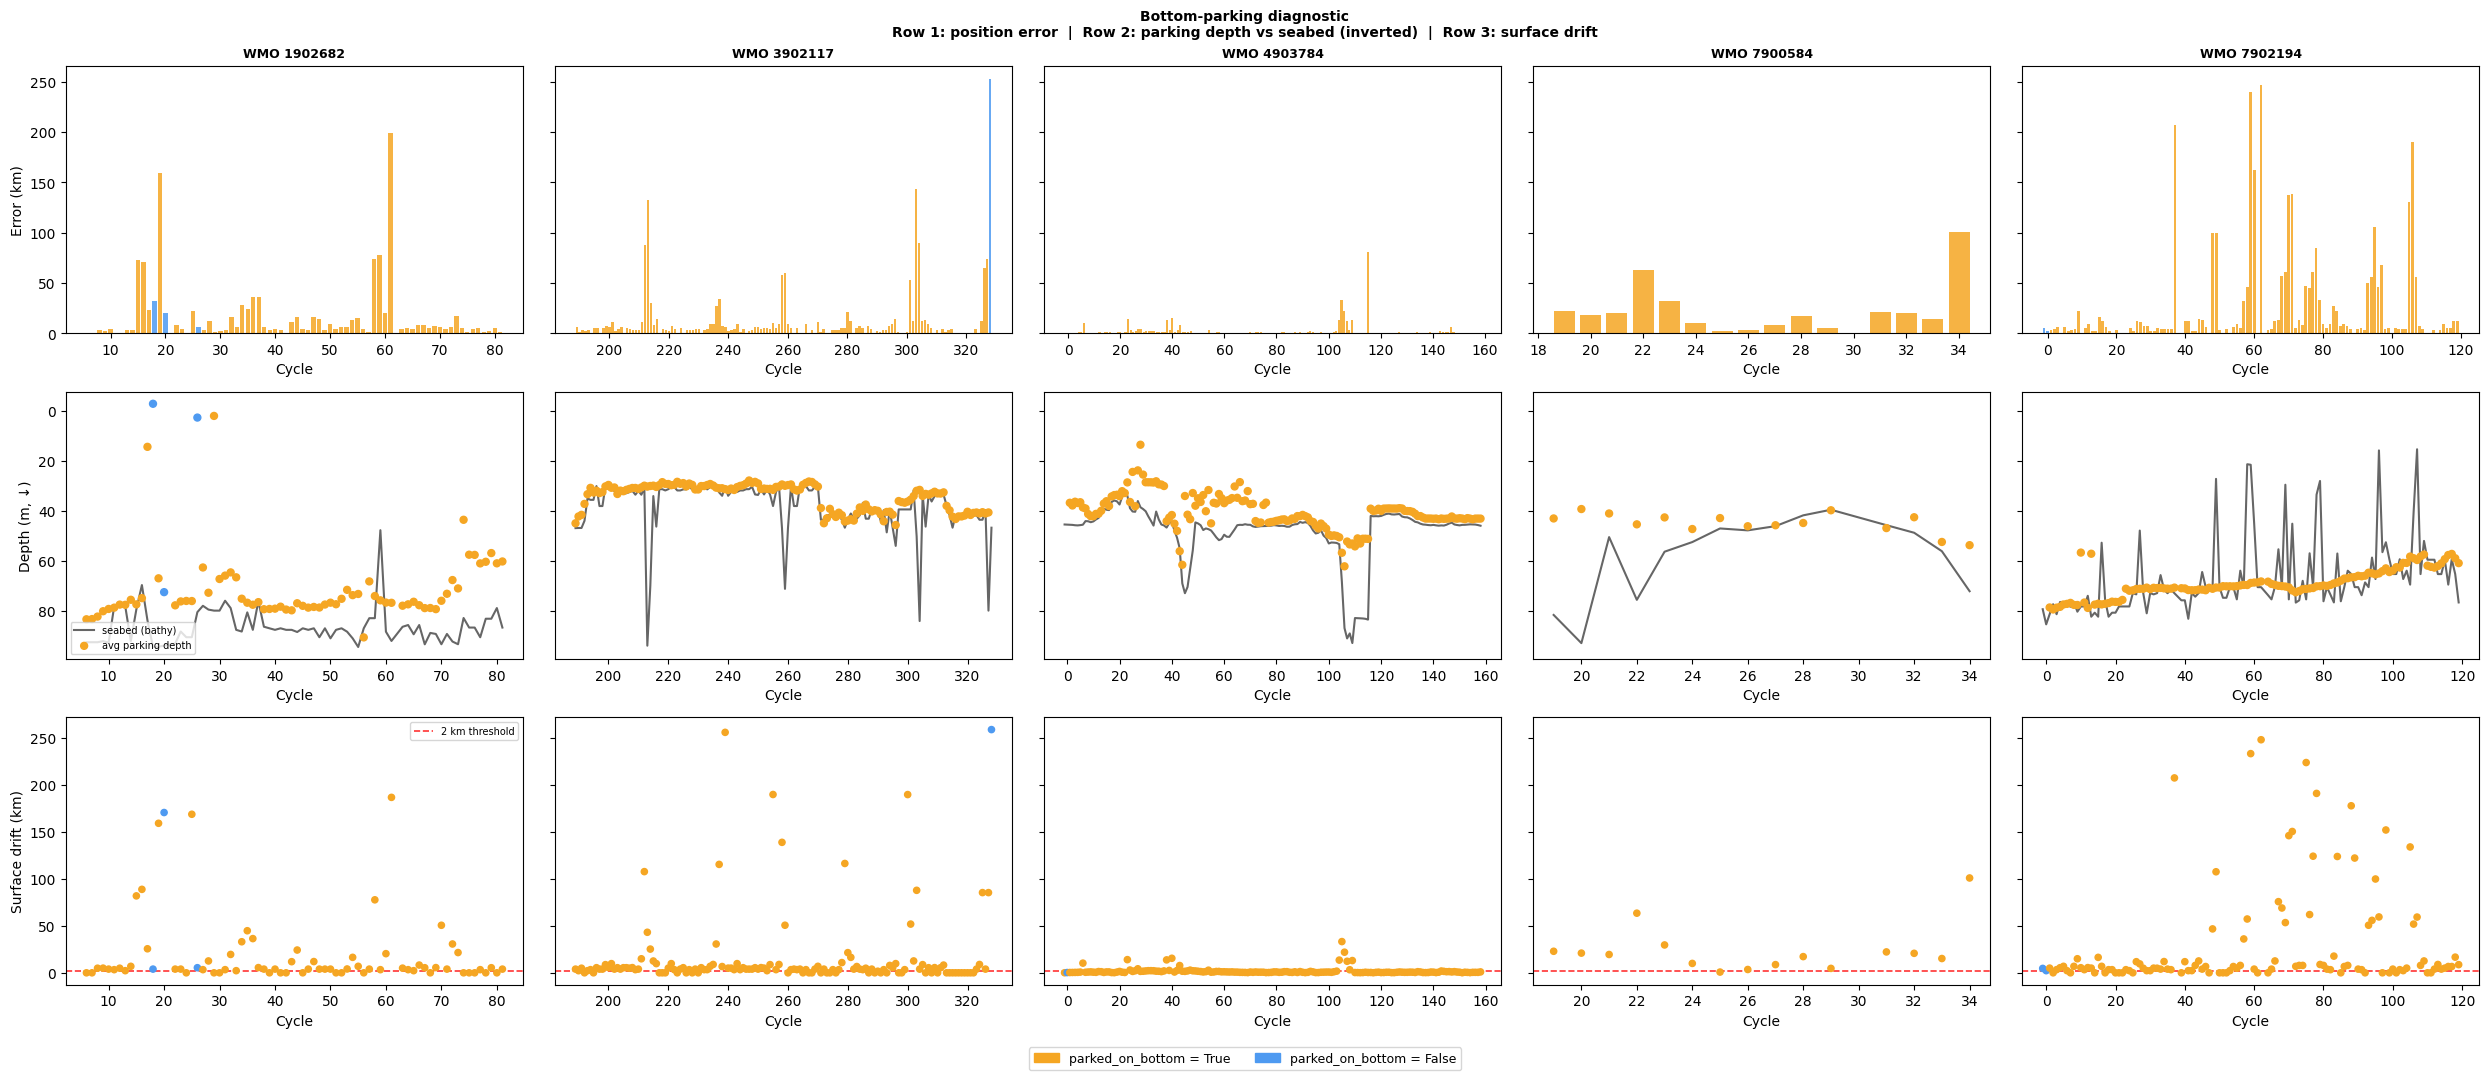

In [27]:
# ── Cell 6d: Bottom-parking diagnostic — one column per float ─────────────────
# Row 1: error_km coloured by parked_on_bottom classification
# Row 2: avg_bottom_depth_dbar (scatter) vs bathy_depth_m (line) — depth axis inverted
# Row 3: drift_km with 2 km threshold — the raw signal driving the classification
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

_required = {"avg_bottom_depth_dbar", "bathy_depth_m", "drift_km"}
if not _required.issubset(all_df.columns):
    missing = _required - set(all_df.columns)
    raise RuntimeError(
        f"Columns {missing} missing from all_df. "
        "Set FORCE_RERUN = True in Cell 6 and re-run it to rebuild the cache."
    )

wmo_list = sorted(all_df["wmo"].unique())
n = len(wmo_list)

C_PARK  = "#f5a623"   # orange  — parked_on_bottom = True
C_DRIFT = "#4e9af1"   # blue    — parked_on_bottom = False

fig, axes = plt.subplots(3, n, figsize=(5 * n, 11), sharey="row")
if n == 1:
    axes = axes.reshape(3, 1)

fig.suptitle(
    "Bottom-parking diagnostic\n"
    "Row 1: position error  |  Row 2: parking depth vs seabed (inverted)  |  Row 3: surface drift",
    fontsize=10, fontweight="bold",
)

for col, wmo in enumerate(wmo_list):
    sub = all_df[all_df["wmo"] == wmo].sort_values("cycle").copy()
    cyc = sub["cycle"].values
    err = sub["error_km"].values
    pob = sub["parked_on_bottom"].values
    colours = np.where(pob, C_PARK, C_DRIFT)

    ax1, ax2, ax3 = axes[0, col], axes[1, col], axes[2, col]

    # ── Row 1: error_km ───────────────────────────────────────────────────────
    ax1.bar(cyc, err, color=colours, width=0.8, alpha=0.85)
    ax1.set_title(f"WMO {wmo}", fontsize=9, fontweight="bold")
    ax1.set_ylabel("Error (km)" if col == 0 else "")
    ax1.set_xlabel("Cycle")

    # ── Row 2: parking depth vs seabed ───────────────────────────────────────
    park_d = sub["avg_bottom_depth_dbar"].values.astype(float)
    bathy  = sub["bathy_depth_m"].values.astype(float)

    valid_b = ~np.isnan(bathy)
    if valid_b.any():
        ax2.plot(cyc[valid_b], bathy[valid_b], color="black", lw=1.5,
                 alpha=0.6, label="seabed (bathy)", zorder=2)

    valid_p = ~np.isnan(park_d)
    ax2.scatter(cyc[valid_p], park_d[valid_p], c=colours[valid_p],
                s=25, zorder=3, label="avg parking depth")

    ax2.invert_yaxis()
    ax2.set_ylabel("Depth (m, ↓)" if col == 0 else "")
    ax2.set_xlabel("Cycle")
    if col == 0:
        ax2.legend(fontsize=7, loc="lower left")

    # ── Row 3: drift_km ───────────────────────────────────────────────────────
    drift   = sub["drift_km"].values.astype(float)
    valid_d = ~np.isnan(drift)
    ax3.scatter(cyc[valid_d], drift[valid_d], c=colours[valid_d], s=20, zorder=3)
    ax3.axhline(2.0, color="red", lw=1.2, linestyle="--", alpha=0.8,
                label="2 km threshold")
    ax3.set_ylabel("Surface drift (km)" if col == 0 else "")
    ax3.set_xlabel("Cycle")
    if col == 0:
        ax3.legend(fontsize=7)

legend_patches = [
    mpatches.Patch(color=C_PARK,  label="parked_on_bottom = True"),
    mpatches.Patch(color=C_DRIFT, label="parked_on_bottom = False"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=2,
           fontsize=9, framealpha=0.8, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [28]:
# ── Cell 7: Visualisation ─────────────────────────────────────────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots

wmos_done = [w for w in WMOS_TO_ANALYZE if w in all_results and all_results[w]]

# ── 1. Box plot: error distribution per float ─────────────────────────────────
fig1 = go.Figure()
for wmo in wmos_done:
    errs = [r["error_km"] for r in all_results[wmo]]
    fig1.add_trace(go.Box(
        y=errs, name=str(wmo),
        boxpoints="all", jitter=0.3, pointpos=-1.8,
        hovertemplate="Error: %{y:.2f} km<extra>WMO " + str(wmo) + "</extra>",
    ))
fig1.update_layout(
    title="Single-cycle position error by float (reset mode)",
    yaxis_title="Error (km)",
    xaxis_title="Float WMO",
    paper_bgcolor="rgb(15,20,40)", font_color="white", plot_bgcolor="rgb(20,30,50)",
    height=420,
)
fig1.show()

# ── 2. Per-cycle error vs cycle index ─────────────────────────────────────────
fig2 = go.Figure()
for wmo in wmos_done:
    rows = all_results[wmo]
    fig2.add_trace(go.Scatter(
        x=[r["cycle"] for r in rows],
        y=[r["error_km"] for r in rows],
        mode="lines+markers", name=str(wmo),
        hovertemplate="Cycle %{x} — %{y:.2f} km<extra>WMO " + str(wmo) + "</extra>",
    ))
fig2.update_layout(
    title="Per-cycle position error vs cycle number",
    xaxis_title="Cycle number",
    yaxis_title="Error (km)",
    paper_bgcolor="rgb(15,20,40)", font_color="white", plot_bgcolor="rgb(20,30,50)",
    legend=dict(bgcolor="rgba(0,0,0,0.5)"),
    height=420,
)
fig2.show()

# ── 3. Summary table ──────────────────────────────────────────────────────────
rows = []
for wmo in wmos_done:
    errs = [r["error_km"] for r in all_results[wmo]]
    rows.append({
        "WMO": wmo,
        "N cycles": len(errs),
        "Mean (km)": round(np.mean(errs), 2),
        "Median (km)": round(np.median(errs), 2),
        "P90 (km)": round(np.percentile(errs, 90), 2),
        "Max (km)": round(np.max(errs), 2),
    })
print(pd.DataFrame(rows).to_string(index=False))

    WMO  N cycles  Mean (km)  Median (km)  P90 (km)  Max (km)
7902194       119      25.63         5.56     71.80    246.85
4903784       160       2.36         0.69      3.26     81.06
1902682        74      16.61         5.66     35.07    198.82
7900584        15      23.90        18.61     50.58    101.19
3902117       140      11.99         4.14     15.02    253.34


## Q estimation — pooled across all floats

Uses the Cartesian residuals and cycle durations captured in Cell 6.  
**Only free-drifting cycles** (`parked_on_bottom == False`) are included — bottom-parked floats are anchored and contribute no current-driven uncertainty.

- **Q_pos** — pooled estimator `mean(ε²/T)` with scatter coloured by WMO; per-float estimates in the summary table let you check inter-float consistency.  
- **Q_bias** — successive bias increments `var(Δb̂)/T̄`; bias time-series per float reveal whether the "apparent current error" is geographically or temporally structured.

Drifting cycles: 295 / 509 total  (5 floats)
Q_pos_x = 12717.3888 m²/s  (σ = 6766.3 m/√hr)
Q_pos_y = 469.3019 m²/s  (σ = 1299.8 m/√hr)
Q_pos   = 6593.3454 m²/s  (pooled isotropic, σ = 4872.0 m/√hr)
Current: Q_pos = 4.0000 m²/s  (σ = 120 m/√hr)


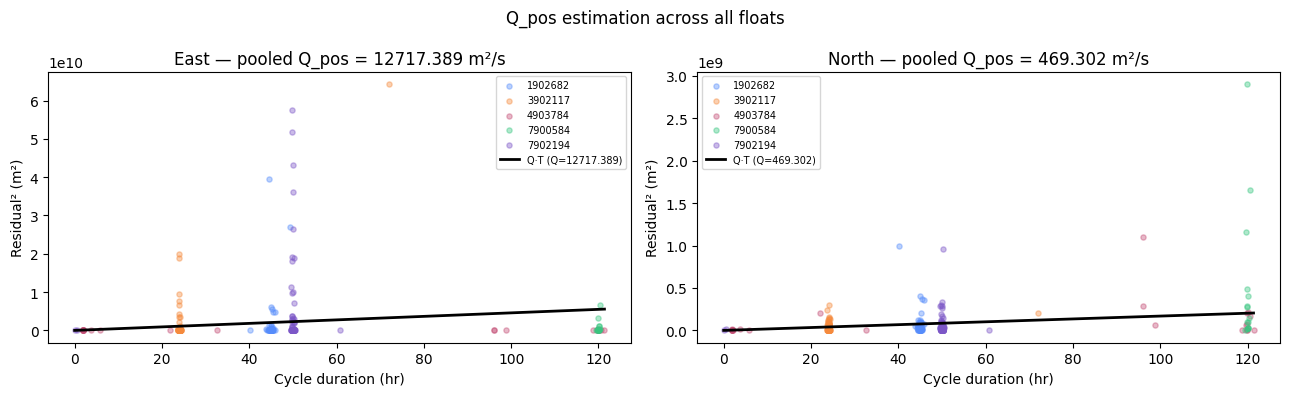

In [11]:
# ── Cell 9: Q_pos — pooled scatter coloured by float ──────────────────────────
import matplotlib.pyplot as plt

df_drifting = all_df[all_df["parked_on_bottom"] == False].copy()
print(f"Drifting cycles: {len(df_drifting)} / {len(all_df)} total  "
      f"({df_drifting['wmo'].nunique()} floats)")

T  = df_drifting["T_s"].values
xr = df_drifting["x_res_m"].values
yr = df_drifting["y_res_m"].values

Q_pos_x = np.mean(xr**2 / T)
Q_pos_y = np.mean(yr**2 / T)
Q_pos   = (Q_pos_x + Q_pos_y) / 2

print(f"Q_pos_x = {Q_pos_x:.4f} m²/s  (σ = {np.sqrt(Q_pos_x)*60:.1f} m/√hr)")
print(f"Q_pos_y = {Q_pos_y:.4f} m²/s  (σ = {np.sqrt(Q_pos_y)*60:.1f} m/√hr)")
print(f"Q_pos   = {Q_pos:.4f} m²/s  (pooled isotropic, σ = {np.sqrt(Q_pos)*60:.1f} m/√hr)")
print(f"Current: Q_pos = {(120/60)**2:.4f} m²/s  (σ = 120 m/√hr)")

T_line = np.linspace(0, T.max(), 200)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colours = plt.rcParams["axes.prop_cycle"].by_key()["color"]
wmo_list = sorted(df_drifting["wmo"].unique())
colour_map = {wmo: colours[i % len(colours)] for i, wmo in enumerate(wmo_list)}

for ax, res, Q_ax, label in [
    (axes[0], xr, Q_pos_x, "East"),
    (axes[1], yr, Q_pos_y, "North"),
]:
    for wmo in wmo_list:
        mask = df_drifting["wmo"].values == wmo
        ax.scatter(T[mask] / 3600, res[mask]**2,
                   alpha=0.4, s=14, color=colour_map[wmo], label=str(wmo))
    ax.plot(T_line / 3600, Q_ax * T_line, "k-", lw=2, label=f"Q·T (Q={Q_ax:.3f})")
    ax.set_xlabel("Cycle duration (hr)")
    ax.set_ylabel("Residual² (m²)")
    ax.set_title(f"{label} — pooled Q_pos = {Q_ax:.3f} m²/s")
    ax.legend(fontsize=7)
plt.suptitle("Q_pos estimation across all floats")
plt.tight_layout()
plt.show()

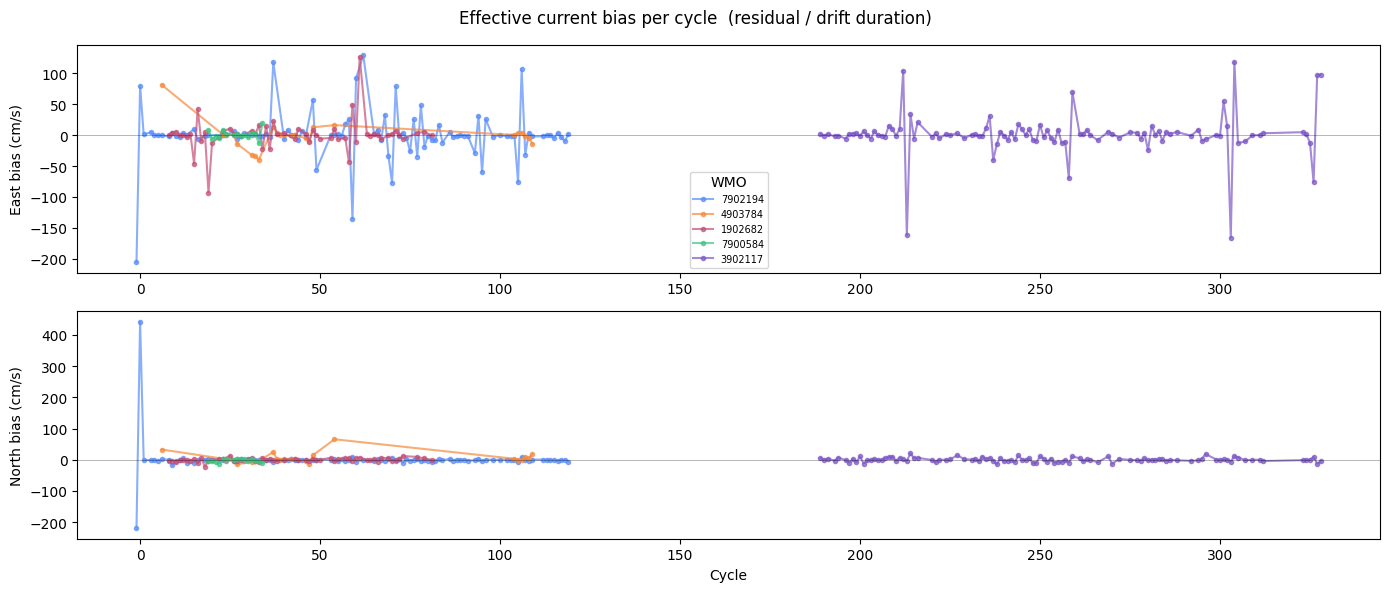

Q_bias (pooled) = 1.6169e-06 (m/s)²/s  (σ = 0.07630 (m/s)/√hr)
Current default = 6.9444e-05 (m/s)²/s


In [12]:
# ── Cell 10: Q_bias — pooled + per-float ──────────────────────────────────────
import matplotlib.pyplot as plt

per_float_Q = {}   # wmo → (Q_pos, Q_bias)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

for wmo in WMOS_TO_ANALYZE:
    sub = df_drifting[df_drifting["wmo"] == wmo].sort_values("cycle")
    if len(sub) < 3:
        continue

    bx = (sub["x_res_m"] / sub["T_drift_s"]).values
    by = (sub["y_res_m"] / sub["T_drift_s"]).values
    T_arr = sub["T_drift_s"].values
    T_mean = np.mean(T_arr[:-1])

    delta_bx = np.diff(bx)
    delta_by = np.diff(by)
    Q_bias_x_w = np.var(delta_bx) / T_mean
    Q_bias_y_w = np.var(delta_by) / T_mean
    Q_pos_w    = (np.mean(sub["x_res_m"].values**2 / sub["T_s"].values) +
                  np.mean(sub["y_res_m"].values**2 / sub["T_s"].values)) / 2
    per_float_Q[wmo] = (Q_pos_w, (Q_bias_x_w + Q_bias_y_w) / 2)

    axes[0].plot(sub["cycle"], bx * 100, ".-", alpha=0.7, label=str(wmo))
    axes[1].plot(sub["cycle"], by * 100, ".-", alpha=0.7, label=str(wmo))

axes[0].axhline(0, color="black", lw=0.5, alpha=0.4)
axes[0].set_ylabel("East bias (cm/s)")
axes[0].legend(title="WMO", fontsize=7)
axes[1].axhline(0, color="black", lw=0.5, alpha=0.4)
axes[1].set_ylabel("North bias (cm/s)")
axes[1].set_xlabel("Cycle")
plt.suptitle("Effective current bias per cycle  (residual / drift duration)")
plt.tight_layout()
plt.show()

# Pooled Q_bias
bx_all = (df_drifting["x_res_m"] / df_drifting["T_drift_s"]).values
by_all = (df_drifting["y_res_m"] / df_drifting["T_drift_s"]).values
T_mean_all = np.mean(df_drifting["T_drift_s"].values)
Q_bias = ((np.var(np.diff(bx_all)) + np.var(np.diff(by_all))) / 2) / T_mean_all
print(f"Q_bias (pooled) = {Q_bias:.4e} (m/s)²/s  "
      f"(σ = {np.sqrt(Q_bias)*60:.5f} (m/s)/√hr)")
print(f"Current default = {(0.5/60)**2:.4e} (m/s)²/s")

In [13]:
# ── Cell 11: Q summary — pooled estimate ready to paste into noise.py ─────────
sigma_pos_m_per_sqrt_hr    = np.sqrt(Q_pos)  * 60
sigma_bias_ms_per_sqrt_hr  = np.sqrt(Q_bias) * 60

print("=" * 55)
print("POOLED Q ESTIMATE — paste into src/noise.py")
print("=" * 55)
print(f"""
_SIGMA_POS  = {sigma_pos_m_per_sqrt_hr:.2f} / 60   # {sigma_pos_m_per_sqrt_hr:.1f} m/√hr  → Q_pos  = {Q_pos:.4f} m²/s
_SIGMA_BIAS = {sigma_bias_ms_per_sqrt_hr:.6f} / 60  # {sigma_bias_ms_per_sqrt_hr:.6f} (m/s)/√hr → Q_bias = {Q_bias:.4e} (m/s)²/s
""")
print("Compared to current defaults:")
print(f"  Q_pos  : {(120/60)**2:.4f}  →  {Q_pos:.4f}  m²/s          (ratio {Q_pos/(120/60)**2:.2f}x)")
print(f"  Q_bias : {(0.5/60)**2:.4e}  →  {Q_bias:.4e} (m/s)²/s  (ratio {Q_bias/(0.5/60)**2:.2f}x)")

# Per-float table
print("\nPer-float estimates:")
tbl = []
for wmo in per_float_Q:
    qp, qb = per_float_Q[wmo]
    n = (all_df["wmo"] == wmo).sum()
    tbl.append({"WMO": wmo, "N drifting": n,
                "Q_pos (m²/s)": round(qp, 4),
                "σ_pos (m/√hr)": round(np.sqrt(qp)*60, 1),
                "Q_bias (m/s)²/s": f"{qb:.2e}"})
print(pd.DataFrame(tbl).to_string(index=False))

POOLED Q ESTIMATE — paste into src/noise.py

_SIGMA_POS  = 4871.97 / 60   # 4872.0 m/√hr  → Q_pos  = 6593.3454 m²/s
_SIGMA_BIAS = 0.076296 / 60  # 0.076296 (m/s)/√hr → Q_bias = 1.6169e-06 (m/s)²/s

Compared to current defaults:
  Q_pos  : 4.0000  →  6593.3454  m²/s          (ratio 1648.34x)
  Q_bias : 6.9444e-05  →  1.6169e-06 (m/s)²/s  (ratio 0.02x)

Per-float estimates:
    WMO  N drifting  Q_pos (m²/s)  σ_pos (m/√hr) Q_bias (m/s)²/s
7902194         119    10124.7227         6037.3        3.04e-06
4903784         160      550.5652         1407.8        2.02e-07
1902682          74     5407.3336         4412.1        5.16e-07
7900584          16     1623.0126         2417.2        1.95e-08
3902117         140     6044.3627         4664.7        1.97e-06
